In [ ]:
import imageio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.ndimage as ndi
import numpy as np
import itertools
import pandas as pd

from module.Analysis import *

from skimage import exposure, filters, morphology, measure, color, img_as_float, metrics

/tmp/ipykernel_3121/2763168885.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread("../dataset/Assigment1/retina/normal2.jpg")


(1580, 1554, 3) float64


(-0.5, 1553.5, 1579.5, -0.5)

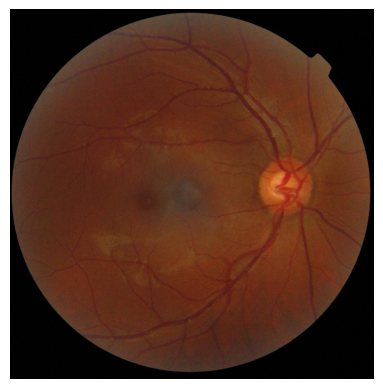

In [3]:
im = imageio.imread("../dataset/Assigment1/retina/normal2.jpg")
im = img_as_float(im)

print(im.shape, im.dtype)

plt.imshow(im)
plt.axis("off")

MSE: 0.043882915211816635
1 PSNR: 61.70784890134074
MSE: 0.04543436928986386
2 PSNR: 61.556958572200585
MSE: 0.047062358355048566
3 PSNR: 61.40406674429926
MSE: 0.050359068591292064
5 PSNR: 61.110026717871875
MSE: 0.05361698200911759
7 PSNR: 60.8377799608629
MSE: 0.03132357401990418
3 PSNR: 63.17209051652901
MSE: 0.032334840359757144
5 PSNR: 63.034096397334594
MSE: 0.03176420468179058
7 PSNR: 63.111423750084924
MSE: 0.03302706144745783
11 PSNR: 62.942104264113254
           Method  Sigma  Median  Clip       MSE       PSNR
5    Median+CLAHE    NaN     3.0  0.01  0.031324  63.172091
7    Median+CLAHE    NaN     7.0  0.01  0.031764  63.111424
6    Median+CLAHE    NaN     5.0  0.01  0.032335  63.034096
8    Median+CLAHE    NaN    11.0  0.01  0.033027  62.942104
0  Gaussian+CLAHE    1.0     NaN  0.01  0.043883  61.707849
1  Gaussian+CLAHE    2.0     NaN  0.01  0.045434  61.556959
2  Gaussian+CLAHE    3.0     NaN  0.01  0.047062  61.404067
3  Gaussian+CLAHE    5.0     NaN  0.01  0.050359  61

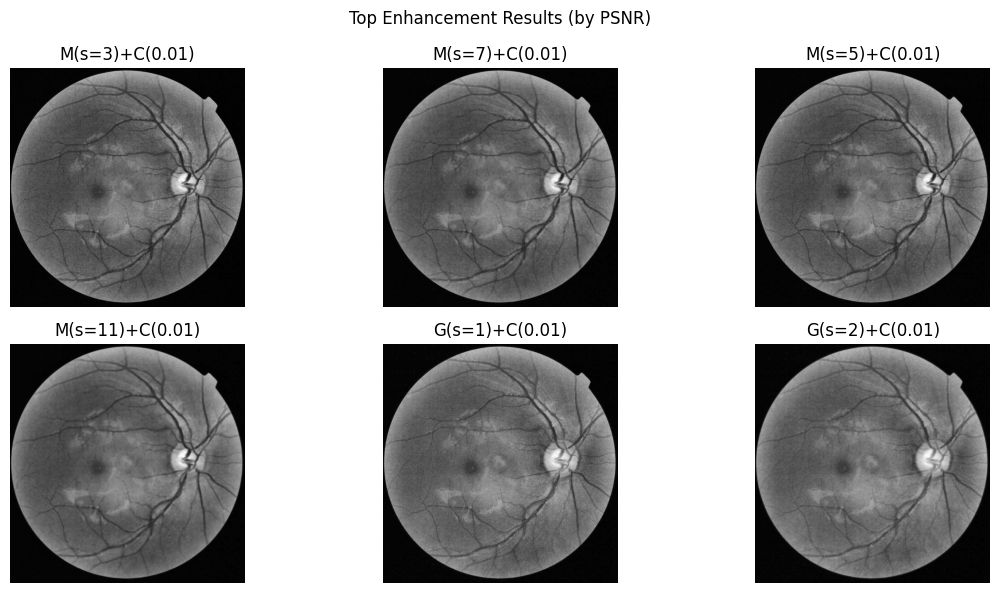

In [4]:
# ---- Parameter Space ----
sigma_values = [1, 2, 3, 5, 7]
median_sizes = [3, 5, 7, 11]
clip_limits = [0.01]

# ---- Storage ----
results = []
records = []

original = im[:,:,1].astype(np.float64)

for sigma, clip in itertools.product(sigma_values, clip_limits):
    filtered = ndi.gaussian_filter(im, sigma=sigma)
    enhanced = exposure.equalize_adapthist(filtered[:,:,1], clip_limit=clip)

    mse = MSE(sigma, original, enhanced)
    psnr = PSNR(sigma, original, enhanced)

    results.append((f"G(s={sigma})+C({clip})", enhanced))
    records.append({
        "Method": "Gaussian+CLAHE",
        "Sigma": sigma,
        "Median": None,
        "Clip": clip,
        "MSE": mse,
        "PSNR": psnr
    })

for size, clip in itertools.product(median_sizes, clip_limits):
    filtered = ndi.median_filter(im, size=size)
    enhanced = exposure.equalize_adapthist(filtered[:,:,1], clip_limit=clip)

    mse = MSE(size, original, enhanced)
    psnr = PSNR(size, original, enhanced)

    results.append((f"M(s={size})+C({clip})", enhanced))
    records.append({
        "Method": "Median+CLAHE",
        "Sigma": None,
        "Median": size,
        "Clip": clip,
        "MSE": mse,
        "PSNR": psnr
    })

df = pd.DataFrame(records)

df_sorted = df.sort_values(by="PSNR", ascending=False)

print(df_sorted.head(10))

top_n = 6
top_indices = df_sorted.head(top_n).index

plt.figure(figsize=(12,6))
for i, idx in enumerate(top_indices):
    name, img = results[idx]
    plt.subplot(2, 3, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(name)
    plt.axis('off')

plt.suptitle("Top Enhancement Results (by PSNR)")
plt.tight_layout()
plt.show()

Median Filter PSNR: 63.11265196005938
MSE: 0.03175522285066004

  Optic Disc Center : (1172.0, 757.0)
  Estimated Radius  : 41 px
ENL Result: 6.112429901084575
CNR result : 0


/home/putra/project/College/PCM/.env/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/putra/project/College/PCM/.env/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/putra/project/College/PCM/.env/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/putra/project/College/PCM/.env/lib/python3.8/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/putra/project/College/PCM/.env/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
Clipping input data to the valid ra

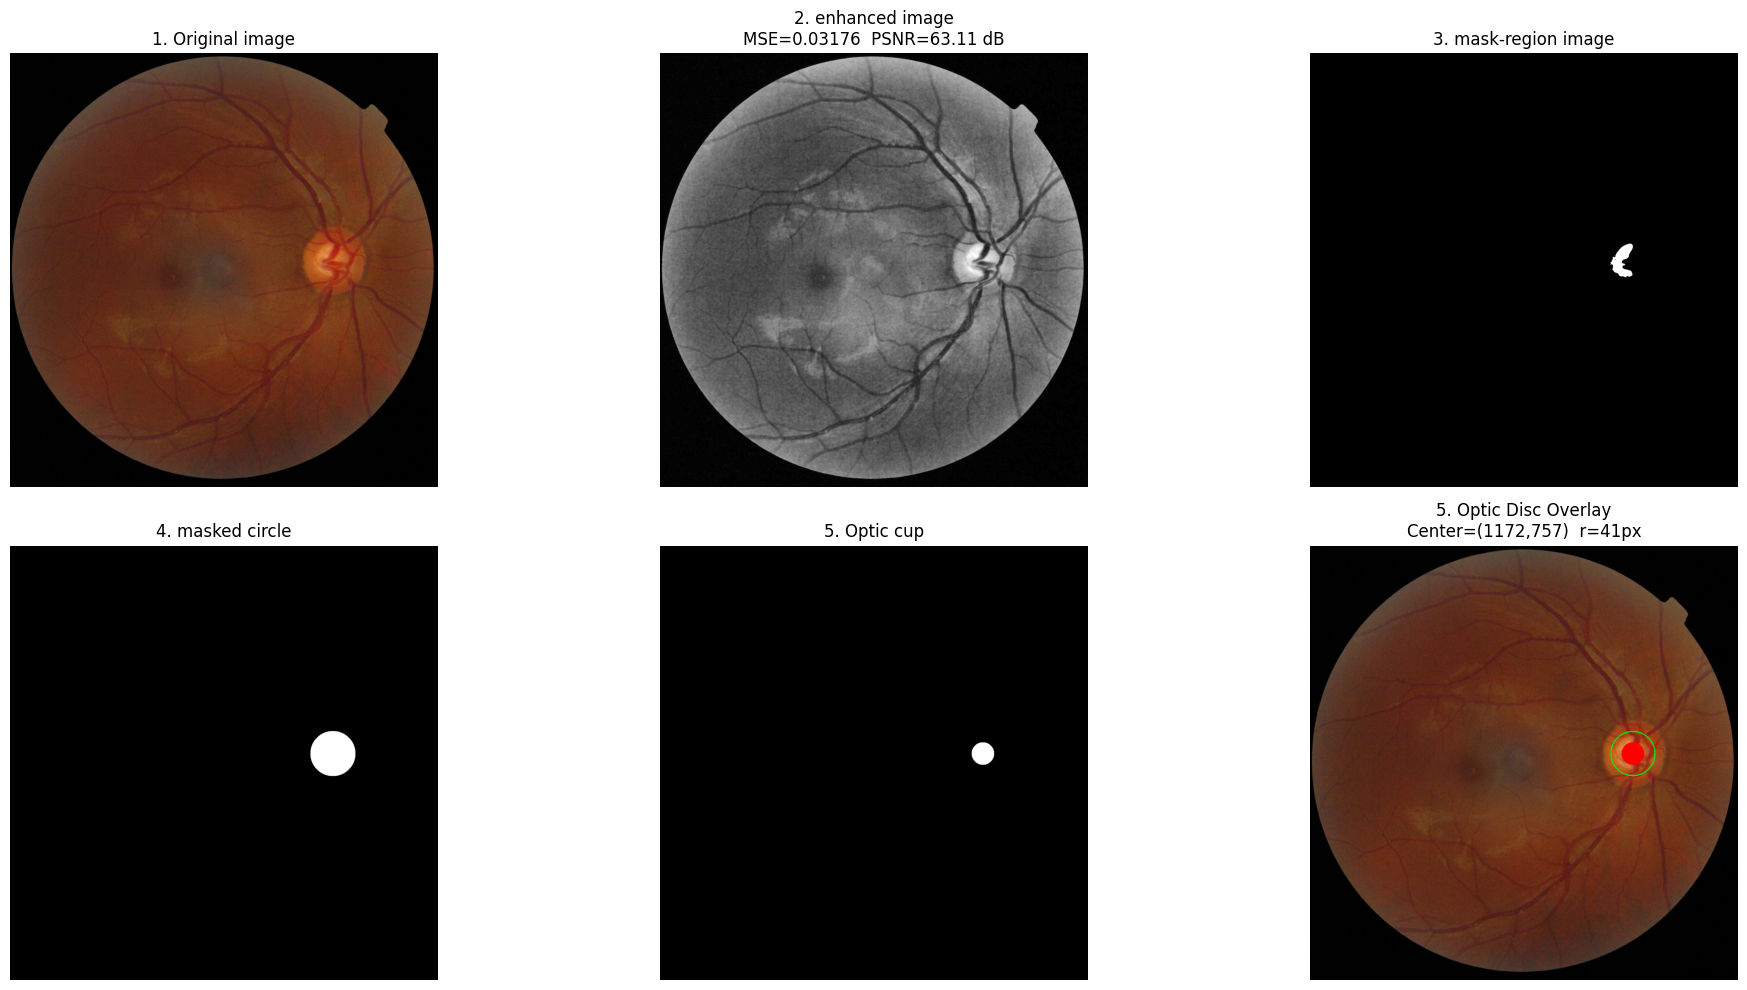

In [7]:
image = ndi.median_filter(im[:,:,1], size=5)
enhanced = exposure.equalize_adapthist(image, clip_limit=0.01)

psnr = PSNR("Median Filter", im[:,:,1], enhanced)
mse = MSE("Median Filter", im[:,:,1], enhanced)

mask = enhanced > 0.75
mask = morphology.remove_small_objects(mask, 2500)

labeled = measure.label(mask)
regions = measure.regionprops(labeled, intensity_image=enhanced)

if regions:
    best_region = max(regions, key=lambda r: r.mean_intensity)
    
    min_row, min_col, max_row, max_col = best_region.bbox

    cx = max_col                          
    cy = (min_row + max_row) / 2          

    area = best_region.area
    rad  = int(np.sqrt(area / np.pi))
else:
    cy, cx = im.shape[0] // 2, im.shape[1] // 2
    rad = 50
    print("no region found")
    
print(f"\n  Optic Disc Center : ({cx:.1f}, {cy:.1f})")
print(f"  Estimated Radius  : {rad} px")

Y, X = np.ogrid[:im.shape[0], :im.shape[1]]
circle_mask = ((X - cx) ** 2 + (Y - cy) ** 2) <= ((rad * 2) ** 2)
optic_cup = ((X - cx) ** 2 + (Y - cy) ** 2) <= (rad ** 2)

border_mask = im[:,:,1] > 0.5  # singkirkan area hitam di luar fundus

region_inside  = enhanced[circle_mask]
region_outside = enhanced[~circle_mask & border_mask]

ENL(region_inside, region_outside)
CNR(region_inside, region_outside)

fig, ax = plt.subplots(2,3, figsize=(21,10))

ax[0,0].imshow(im, cmap="gray")
ax[0,0].set_title("1. Original image")
ax[0,0].axis("off")

ax[0,1].imshow(enhanced, cmap="gray")
ax[0,1].set_title(f"2. enhanced image\nMSE={mse:.5f}  PSNR={psnr:.2f} dB")
ax[0,1].axis("off")

ax[0,2].imshow(mask, cmap="gray")
ax[0,2].set_title("3. mask-region image")
ax[0,2].axis("off")

ax[1,0].imshow(circle_mask, cmap="gray")
ax[1,0].set_title("4. masked circle")
ax[1,0].axis("off")

ax[1,1].imshow(optic_cup, cmap="gray")
ax[1,1].set_title("5. Optic cup")
ax[1,1].axis("off")

overlay = im.copy()
circle_edge = circle_mask ^ morphology.binary_erosion(circle_mask, morphology.disk(4))
overlay[circle_edge] = [0, 255, 0] 
overlay[optic_cup] = [255,0,0]

ax[1, 2].imshow(overlay)
ax[1, 2].plot(cx, cy, 'r+', markersize=12, markeredgewidth=2)
ax[1, 2].set_title(f"5. Optic Disc Overlay\nCenter=({cx:.0f},{cy:.0f})  r={rad}px")
ax[1, 2].axis("off")

plt.tight_layout()

In [6]:
od_area = np.sum(circle_mask)  # Total optic disk area (pixel)
oc_area = np.sum(optic_cup)    # Total optic cup area (pixel)
cdr = oc_area / od_area if od_area > 0 else 0

data = []

od_pixels = enhanced[circle_mask]
oc_pixels = enhanced[optic_cup]

od_mean_intensity = np.mean(od_pixels)
od_std_intensity = np.std(od_pixels)
oc_mean_intensity = np.mean(oc_pixels)
oc_std_intensity = np.std(oc_pixels)

features = {
    "od_area(pixel)": od_area,
    "oc_area(pixel)": oc_area,
    "cdr": cdr,
    "oc_radius(pixel)": rad,
    "od_radius(pixel)": rad * 2,
    "od_mean_intensity": od_mean_intensity,
    "od_std_intensity": od_std_intensity,
    "oc_mean_intensity": oc_mean_intensity,
    "oc_std_intensity": oc_std_intensity
}

data = pd.DataFrame([features])

data

,od_area(pixel),oc_area(pixel),cdr,oc_radius(pixel),od_radius(pixel),od_mean_intensity,od_std_intensity,oc_mean_intensity,oc_std_intensity
0,21101,5261,0.249325,41,82,0.588403,0.237995,0.57618,0.239771
